# Replication of reskilling analysis from MSc thesis
Felix Zaussinger | 15.09.2022

**Core Analysis Goal(s)**
1. Replicate thesis approach based on updated data
2. Decide how to deal with skewed distribution when working with COOC matrix compared to ESCO matrix tables or Kanders Matrix
3. Understand and write down all of the assumptions that I make and reflect whether they are robust enough

**Key Insight(s)**
1. Replication based on ESCO v.1.1 is working!
2.
3.

In [288]:
import os
import scipy
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

from tqdm import tqdm
from mapping_career_causeways.compare_nodes_utils import find_closest

import seaborn as sns
import matplotlib.pyplot as plt

# load paths
from src import utils
from src.data.lfs import EuLfs
from src.modelling.reskilling import ReskillingPathways
from src.data.framework import Esco

useful_paths = utils.UsefulPaths()

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
pd.options.display.float_format = "{:,.2f}".format

sns.set_context("paper", font_scale=1.5, rc={"figure.dpi": 72})
sns.set_style("ticks")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Load data

##### Auxillary data

In [406]:
earnings_deciles = pd.read_csv(
    os.path.join(
        useful_paths.data_raw, "metadata", "earnings_per_deciles.csv"
    ),
)

# Read geodata with NUTS regions
gdf = gpd.read_file(
    os.path.join(
        useful_paths.data_raw,
        "geodata",
        "NUTS_RG_03M_2021_4326_LEVL_2",
        "NUTS_RG_03M_2021_4326_LEVL_2.shp",
    )
)

In [407]:
earnings_deciles

,country,decile,annual_earnings,year
0,DE,1,7635,2016
1,DE,2,11970,2016
2,DE,3,14817,2016
3,DE,4,17256,2016
4,DE,5,19692,2016
5,DE,6,22243,2016
6,DE,7,25088,2016
7,DE,8,28832,2016
8,DE,9,34299,2016
9,DE,10,55368,2016


##### LFS data

In [415]:
# esco data
esco = Esco()

# EU-LFS data
config = utils.load_config(os.path.join(useful_paths.config_dir, "eu_lfs_config.yml"))
lfs = EuLfs(config=config)

df_all = lfs.read_preprocessed_file(
    year=2019, input_fname_lfs="eu_lfs_merged_{year}_with_final_unweighted_shares"
)

df_all["INCDECIL"] = df_all["INCDECIL"].astype(float)

Subset data for Germany and combine with earnings deciles

In [416]:
df_all = pd.merge(
    df_all, earnings_deciles, left_on=["COUNTRYW", "INCDECIL"], right_on=["country", "decile"], how="left"
)

# define the GBN category of an ISCO 3D group as the one with the highest fraction (of ESCO occupations)
df_all["category"] = df_all[
    ["share_green", "share_brown_sl", "share_neutral_sl"]
].idxmax(axis=1)

df_all = df_all.replace(
    to_replace={
        "category": {
            "share_green": "green",
            "share_brown_sl": "brown",
            "share_neutral_sl": "neutral",
        }
    }
)
df_all

,AGE,COEFF,COEFF_share_brown_sl,COEFF_share_brown_slt,COEFF_share_green,COEFF_share_neutral_sl,COEFF_share_neutral_slt,COUNTRY,COUNTRYW,DEGURBA,...,share_brown_sl,share_brown_slt,share_green,share_neutral_sl,share_neutral_slt,country,decile,annual_earnings,year,category
0,52,82.55,2.80,1.40,0.00,79.75,81.15,AT,AT,3,...,0.03,0.02,0.00,0.97,0.98,NaN,NaN,NaN,NaN,neutral
1,17,82.55,0.00,0.00,8.01,74.54,74.54,AT,AT,3,...,0.00,0.00,0.10,0.90,0.90,NaN,NaN,NaN,NaN,neutral
2,42,47.23,0.00,0.00,0.00,47.23,47.23,AT,AT,3,...,0.00,0.00,0.00,1.00,1.00,NaN,NaN,NaN,NaN,neutral
3,47,52.95,0.00,0.00,0.00,52.95,52.95,AT,AT,3,...,0.00,0.00,0.00,1.00,1.00,NaN,NaN,NaN,NaN,neutral
4,42,75.86,0.00,0.00,0.00,75.86,75.86,AT,AT,2,...,0.00,0.00,0.00,1.00,1.00,NaN,NaN,NaN,NaN,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1417927,17,"1,100.14",0.00,0.00,0.00,"1,100.14","1,100.14",UK,UK,1,...,0.00,0.00,0.00,1.00,1.00,NaN,NaN,NaN,NaN,neutral
1417928,52,"1,790.61",246.98,61.75,370.47,"1,173.16","1,358.39",UK,UK,3,...,0.14,0.03,0.21,0.66,0.76,NaN,NaN,NaN,NaN,neutral
1417929,57,"1,858.68",0.00,0.00,168.97,"1,689.71","1,689.71",UK,UK,2,...,0.00,0.00,0.09,0.91,0.91,NaN,NaN,NaN,NaN,neutral
1417930,57,"1,723.30",0.00,0.00,0.00,"1,723.30","1,723.30",UK,UK,2,...,0.00,0.00,0.00,1.00,1.00,NaN,NaN,NaN,NaN,neutral


WHAT DO I NEED THIS FOR?

In [419]:
# Aggregating the shares by their mean yields the same shares because they dont differ within a 3-digit group
agg_dict = {
    "COEFF": np.sum,
    "INCDECIL": np.median,
    "share_green": np.mean,
    "share_brown_sl": np.mean,
    "share_brown_slt": np.mean,
    "share_neutral_sl": np.mean,
    "annual_earnings": np.mean,
}
isco3d_avg = df_all.groupby(["ISCO", "ISCO3D_label"]).aggregate(agg_dict)

# define the GBN category of an ISCO 3D group as the one with the highest fraction (of ESCO occupations)
isco3d_avg["category"] = isco3d_avg[
    ["share_green", "share_brown_sl", "share_neutral_sl"]
].idxmax(axis=1)

isco3d_avg = isco3d_avg.replace(
    to_replace={
        "category": {
            "share_green": "green",
            "share_brown_sl": "brown",
            "share_neutral_sl": "neutral",
        }
    }
)

isco3d_avg

,,COEFF,INCDECIL,share_green,share_brown_sl,share_brown_slt,share_neutral_sl,annual_earnings,category
ISCO,ISCO3D_label,,,,,,,,
111,Legislators and senior officials,"280,150.85",9.50,0.00,0.00,0.00,1.00,"43,087.55",neutral
112,Managing directors and chief executives,"1,293,537.40",10.00,0.00,0.00,0.00,1.00,"43,928.25",neutral
121,Business services and administration managers,"2,215,152.38",9.00,0.03,0.00,0.00,0.97,"40,488.32",neutral
122,"Sales, marketing and development managers","1,324,744.35",10.00,0.00,0.00,0.00,1.00,"40,727.26",neutral
131,"Production managers in agriculture, forestry and fisheries","124,111.12",9.00,0.00,0.00,0.00,1.00,NaN,neutral
...,...,...,...,...,...,...,...,...,...
941,Food preparation assistants,"1,902,485.98",2.00,0.00,0.00,0.00,1.00,"12,799.52",neutral
951,Street and related service workers,"33,718.17",1.00,0.00,0.00,0.00,1.00,NaN,neutral
952,Street vendors (excluding food),"158,663.70",2.00,0.00,0.00,0.00,1.00,NaN,neutral


#### Initialise reskilling simulation

In [423]:
# reskilling simulations
osm_version = "weighted"
sim_metric = "cooc"
diagonal_zeros = False

rp = ReskillingPathways(osm_version=osm_version, sim_metric=sim_metric, lfs_data=df_all)

In [388]:
df_occs = rp.get_occs()

In [392]:
# merge to df
df_occs_metadata = pd.merge(
    df_occs,
    isco3d_avg.reset_index(),
    left_on="code",
    right_on="ISCO",
    how="left",
).drop(["ISCO3D_label"], axis=1)

#### Regional availability of target occupations

Each region contains almost > 87% of all unique occupations

In [420]:
df_de = df_all[df_all.COUNTRYW == "DE"]

In [182]:
n_isco_max = df_de.ISCO.unique().shape[0]
occ_number_by_nuts2_and_isco3 = df_de.groupby(["NUTS_ID", "ISCO3D_label"])["COEFF"].sum()
occ_number_by_nuts2_and_isco3

,n_unique_abs,n_unique_rel
count,38.00,38.00
mean,112.47,0.95
std,2.37,0.02
min,103.00,0.87
25%,111.25,0.93
50%,113.00,0.95
75%,114.00,0.96
max,115.00,0.97


In [183]:
n_unique_occ_by_nuts2 = occ_number_by_nuts2_and_isco3.reset_index().groupby("NUTS_ID")["ISCO3D_label"].count().to_frame()
n_unique_occ_by_nuts2 = n_unique_occ_by_nuts2.rename(columns={"ISCO3D_label": "n_unique_abs"})
n_unique_occ_by_nuts2["n_unique_rel"] = n_unique_occ_by_nuts2["n_unique_abs"] / n_isco_max
n_unique_occ_by_nuts2.describe()

NUTS_ID  ISCO3D_label                                            
DE11     Administration professionals                                37,427.47
         Administrative and specialised secretaries                 103,948.29
         Agricultural, forestry and fishery labourers                 6,283.47
         Animal producers                                               592.28
         Architects, planners, surveyors and designers               26,055.15
                                                                       ...    
DEG0     Veterinary technicians and assistants                          389.89
         Vocational education teachers                                6,449.17
         Waiters and bartenders                                       9,020.33
         Wood processing and papermaking plant operators                153.12
         Wood treaters, cabinet-makers and related trades workers     8,549.19
Name: COEFF, Length: 4274, dtype: float64

#### Computing occupation similarity at ISCO-3D level

Notes
- occupation distance measure at ISCO 3D level (todo: aggregate from ESCO)
- additional covariates: income deciles, skill level as proxy for education, ...
- analysis will be slightly different than the Nesta approach

Questions
- calculate average skill profile of 3D groups is calculated from occ-skills matrix (not possible for Kanders matrix as I miss the input data)

Decision
- use self-calculated, weighted occ-skills matrix
- compute avg skills profiles at ISCO 3D level

In [290]:
# %%time
#
# # Read occupations with their ISCO level
# occ = esco.occupations
# occ["isco_3_digit"] = occ["iscoGroup"].astype(str).str.slice(stop=3)
#
# # read raw occ-skills matrix
#
# # choose OSM version (weighted/unweighted)
# osm_version = "weighted"
#
# # read bipartite adjacency matrix for occupations and skills
# occ_skills_mat = esco.read_occ_skills_matrix(return_version=osm_version)
#
# # Create multiindex
# arrays = [occ.conceptUri.values, occ.isco_3_digit.values]
# tuples = list(zip(*arrays))
# index = pd.MultiIndex.from_tuples(tuples, names=["concept_uri", "isco_3_digit"])
# assert np.alltrue(occ_skills_mat.index.values == occ.conceptUri.values)
#
# # Aggregate original occ-skills matrix to ISCO 3-digit level: average skill vectors
# occ_skills_mat.index = index
# occ_skills_mat_isco3 = occ_skills_mat.groupby(
#     occ_skills_mat.index.get_level_values(1)
# ).mean()
#
# # Calculate occupation similarity matrix at ISCO 3-digit level
# occ_sims_isco3 = np.matmul(
#     occ_skills_mat_isco3.values, occ_skills_mat_isco3.values.transpose()
# )
#
# # Find labels for isco codes
# isco_groups_labels = pd.merge(
#     pd.DataFrame(data=occ_skills_mat_isco3.index.values.astype(str), columns=["code"]),
#     esco.isco_groups[["code", "conceptUri", "preferredLabel"]],
#     on="code",
#     how="left",
# )
#
# # create index for occ sim matrix
# arrays = [
#     isco_groups_labels.conceptUri.values,
#     isco_groups_labels.preferredLabel.values,
# ]
# tuples = list(zip(*arrays))
# index = pd.MultiIndex.from_tuples(tuples, names=["occ_uri", "occ"])
#
# # convert to df
# df_occ_sims = pd.DataFrame(index=index, columns=index, data=occ_sims_isco3)
# df_occs = df_occ_sims.index.to_frame().reset_index(drop=True)
#
# df_occ_sims
#
# # read occ sim matrix
# df_occ_sims = rp.sim_matrix_at_level(level="isco_3_digit")
#
# # create numpy matrix and fill diagonal with zeros (avoid self-transitions)
# similarity_matrix = df_occ_sims.copy().values
# np.fill_diagonal(similarity_matrix, 0)

CPU times: total: 31.2 ms
Wall time: 32.1 ms


In [309]:
# read occ sim matrix
df_occ_sims = rp.sim_matrix_at_level(level="isco_3_digit")

# create numpy matrix and fill diagonal with zeros (avoid self-transitions)
similarity_matrix = df_occ_sims.copy().values
np.fill_diagonal(similarity_matrix, 0)

,conceptUri,preferredLabel,code
2,http://data.europa.eu/esco/isco/C011,Commissioned armed forces officers,011
5,http://data.europa.eu/esco/isco/C021,Non-commissioned armed forces officers,021
8,http://data.europa.eu/esco/isco/C031,"Armed forces occupations, other ranks",031
12,http://data.europa.eu/esco/isco/C111,Legislators and senior officials,111
17,http://data.europa.eu/esco/isco/C112,Managing directors and chief executives,112
...,...,...,...
600,http://data.europa.eu/esco/isco/C941,Food preparation assistants,941
604,http://data.europa.eu/esco/isco/C951,Street and related service workers,951
606,http://data.europa.eu/esco/isco/C952,Street vendors (excluding food),952
609,http://data.europa.eu/esco/isco/C961,Refuse workers,961


#### Calibrate transition thresholds

##### Calculate within-group occupation similarities for different granularity levels

In [291]:
df_occ_sim = rp.df_occ_sim
df_sim_container = rp.calc_sim_means_by_level()

##### Plot results

In [421]:
rp.transition_thresholds = rp.calc_transition_thresholds(show_plots=False)
rp.transition_thresholds

,mean,sd,mean-sd,mean+sd,threshold_category
esco_5_digit,22.35,11.55,10.80,33.90,viable_high
isco_4_digit,14.47,10.79,3.68,25.26,viable
isco_3_digit,9.06,8.06,1.00,17.12,viable_low


<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

##### Percentiles of overall distribution
1.616368047779022 6.500853535353546

In [ ]:
q_viable, q_highly_viable = rp.trans_thresh_pc_approach
print(q_viable, q_highly_viable)

In [ ]:
ax = sns.histplot(df_occ_sims.values.flatten(), color="grey", log_scale=(False, True))
ax.set_xlim(-0.1, 10)
ax.axvline(q_viable, color="lightgreen", label="viable")
ax.axvline(q_highly_viable, color="darkgreen", label="highly viable")
ax.set_ylabel("# Pairwise comparisons")
ax.set_xlabel("Cooccurrence of skills [-]")
plt.legend(loc="upper center", title="threshholds")
sns.despine()

##### Plot occ sim matrix at ISCO 3 digit level

<AxesSubplot:xlabel='Target occupations (isco_3_digit)', ylabel='Source occupations (isco_3_digit)'>

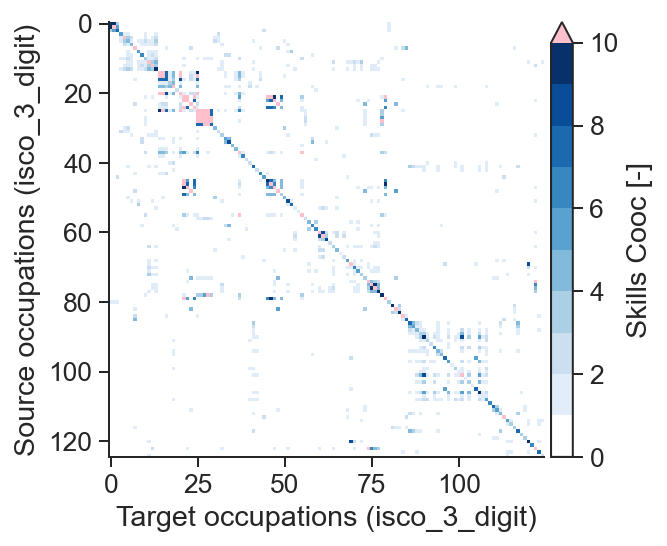

In [321]:
rp.plot_sim_matrix_at_level(vmax=10, mask_upper=False)

##### Plot occupation similarity matrix classified viable/highly viable

In [ ]:
rp.plot_sim_matrix_at_level(level="isco_4_digit", classify=True, mask_upper=False)

#### Transition analysis logic
Base the quantile on the respective quantiles of the viable/highly viable transition categories in the Kanders matrix
- Viable: 96th percentile
- Highly viable: 99th percentile

#### Manually check some transitions

In [422]:
occ = df_occs.loc[df_occs.preferredLabel == "Mining and construction labourers"]
print(occ.preferredLabel)

transitions = find_closest(
    i=occ.index.values[0], similarity_matrix=similarity_matrix, df=df_occs
)

transitions.head(5)

117    Mining and construction labourers
Name: preferredLabel, dtype: object


,conceptUri,preferredLabel,code,similarity
86,http://data.europa.eu/esco/isco/C711,Building frame and related trades workers,711,4.19
87,http://data.europa.eu/esco/isco/C712,Building finishers and related trades workers,712,3.34
112,http://data.europa.eu/esco/isco/C834,Mobile plant operators,834,3.05
41,http://data.europa.eu/esco/isco/C312,"Mining, manufacturing and construction supervi...",312,2.41
94,http://data.europa.eu/esco/isco/C741,Electrical equipment installers and repairers,741,1.42


#### Transition pools (at-risk jobs)

- MSc thesis: coal-related occupations
- Paper: ?

In [185]:
df_transition_pool_core_brown = df_de.loc[df_de.category == "brown"]
df_transition_pool_core_brown.COEFF.sum()

892402.4875

Share-based: above mean of sl or slt

In [186]:
df_transition_pool_aboveavg_brown_sl = df_de.loc[
    df_de["share_brown_sl"] > isco3d_avg["share_brown_sl"].mean()
    ]
df_transition_pool_aboveavg_brown_sl.COEFF.sum()

6830519.8100000005

In [187]:
df_transition_pool_aboveavg_brown_slt = df_de[
    df_de["share_brown_slt"] > isco3d_avg["share_brown_slt"].mean()
    ]
df_transition_pool_aboveavg_brown_slt.COEFF.sum()

8419473.565

MSc thesis: coal-related occupations

In [188]:
dict_transition_pool_thesis = {
    "Mining, manufacturing and construction supervisors": "312",
    "Mining and mineral processing plant operators": "811",
    "Manufacturing, mining, construction, and distribution managers": "132",
    "Mining and construction labourers": "931",
}

industries = [
    "Electricity, Gas, Steam and Air Conditioning Supply",
    "Mining and Quarrying",
]

cond_occupation = df_de.ISCO3D_label.isin(list(dict_transition_pool_thesis.keys()))
cond_industry = df_de.NACE1D_label.isin(industries)

df_transition_pool_thesis = df_de.loc[cond_occupation & cond_industry]

Store options in dict

In [190]:
transition_pool_options = {
    "coal": df_transition_pool_thesis,
    "brown": df_transition_pool_core_brown,
    "aboveavg_brown_sl": df_transition_pool_aboveavg_brown_sl,
    "aboveavg_brown_slt": df_transition_pool_aboveavg_brown_slt,
}

### Analyse number of viable transitions

#### Parameters

In [235]:
from src import plotting_utils

# colorbars
cmap_earnings = plt.get_cmap("coolwarm_r", 8)
cmap_earnings.set_over("darkblue")
cmap_earnings.set_under("darkred")

#cmap_transitions = plotting_utils.discrete_cmap_with_manual_colors(cmap_type="Blues", n_classes=5)
cmap_transitions = plt.get_cmap("Blues", 10)
cmap_transitions.set_over("darkblue")

# upper limits for colorbars
vmax_transitions = 10  # n viable transitions
vmax_wages = 40  # million euro

# initialise dict to store estimates of total wage changes
earnings_losses = {}

# choice of source transition pool
transition_pool = "coal"
df_transition_pool = transition_pool_options[transition_pool]

# choice of weights for transition pool of search occupation: COEFF > COEFF_share_brown_sl > COEFF_share_brown_slt
transition_pool_weights = "COEFF"

# remedy from  thesis
run_skills_continuity_scenarios = False

# create results dir
out_dirname = "{}_occupations_by_{}".format(
    transition_pool, transition_pool_weights.lower()
)
out_dir = os.path.join(useful_paths.figure_dir, "reskilling_simulation", out_dirname)
utils.ccdir(out_dir)

In [192]:
# populate transition pool dict
transition_pool_dict = {}
for i, s in df_transition_pool.iterrows():
    transition_pool_dict[s.ISCO3D_label] = s.ISCO3D

Number of transitioning workers

In [193]:
df_transition_pool.groupby("NACE1D_label").sum().iloc[:, :4].to_csv(
    os.path.join(out_dir, "source_transition_pool.csv")
)

#### Scenario 1: Workers follow closest viable transition regardless of earnings losses (Skills continuity scenario)

In [ ]:
%%time
if run_skills_continuity_scenarios:
    transition_number_data = []
    for i, search_obs in df_transition_pool.iterrows():

        search_label = search_obs.ISCO3D_label
        idx = df_occs.loc[df_occs.occ == search_label].index.values[0]

        target_occs = find_closest(
            i=idx, similarity_matrix=similarity_matrix, df=df_occs_metadata
        )

        target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]
        target_occs_filtered = target_occs_filtered.loc[
            target_occs_filtered.category != "brown"
        ]
        target_occs_filtered = target_occs_filtered.dropna()

        # earnings delta to next closest occupation
        target = target_occs_filtered.head(1)

        # check if viable transition exists
        if not target.empty:
            # Every worker transitions to the next-closest job and I evaluate the wage difference
            search_obs["earnings_delta_closest_switch"] = (
                target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
            )
            search_obs["earnings_delta_closest_switch_sum"] = (
                target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
            ) * search_obs[transition_pool_weights]
            search_obs["n_viable_transitions"] = target_occs_filtered.shape[0]
            search_obs["n_viable_transitions_sum"] = (
                target_occs_filtered.shape[0] * search_obs[transition_pool_weights]
            )
            search_obs["transition_viable"] = True
            search_obs["transition_target"] = target.occ.values[0]
        else:
            # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
            search_obs[
                "earnings_delta_closest_switch"
            ] = search_obs.annual_earnings_2016 * (-1)
            search_obs["earnings_delta_closest_switch_sum"] = (
                search_obs.annual_earnings_2016
                * (-1)
                * search_obs[transition_pool_weights]
            )
            search_obs["n_viable_transitions"] = 0
            search_obs["n_viable_transitions_sum"] = 0
            search_obs["transition_viable"] = False
            search_obs["transition_target"] = None

        transition_number_data.append(search_obs)

    # to df
    df_transition_numbers = pd.concat(transition_number_data, axis=1).T
    df_transition_numbers = df_transition_numbers.infer_objects()

    # Calculate avg number of transitions per threatened job
    df_transition_numbers_by_nuts = df_transition_numbers.groupby("NUTS_ID").sum()
    df_transition_numbers_by_nuts["n_viable_transitions_rel"] = (
        df_transition_numbers_by_nuts.n_viable_transitions_sum
        / df_transition_numbers_by_nuts[transition_pool_weights]
    )

    # to gdf
    gdf_transition_numbers_by_nuts = pd.merge(
        gdf.query("CNTR_CODE == 'DE'"),
        df_transition_numbers_by_nuts.reset_index(),
        on="NUTS_ID",
        how="left",
    )

    # plot
    ax = gdf_transition_numbers_by_nuts.plot(
        column="n_viable_transitions_rel",
        figsize=(10, 10),
        legend=True,
        cmap=cmap_transitions,
        vmin=0,
        vmax=vmax_transitions,
        legend_kwds={
            "label": "Viable transitions per threatened job [-]",
            "fraction": 0.03,
            "extend": "max",
        },
        missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
        edgecolor="grey",
        linewidth=0.5,
    )

    gdf_transition_numbers_by_nuts.apply(
        lambda x: ax.annotate(
            text=x.NUTS_NAME,
            xy=x.geometry.centroid.coords[0],
            ha="center",
            alpha=0.5,
            rotation=0,
            fontsize=8,
        ),
        axis=1,
    )

    ax.axis("off")
    plt.tight_layout()

    # sum of transitions
    cmap = plt.get_cmap("Blues", 6)
    ax = gdf_transition_numbers_by_nuts.plot(
        column="n_viable_transitions",
        figsize=(10, 10),
        legend=True,
        cmap=cmap_transitions,
        legend_kwds={"label": "Viable transitions [-]", "fraction": 0.03},
        missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
        edgecolor="grey",
        linewidth=0.5,
    )
    gdf_transition_numbers_by_nuts.apply(
        lambda x: ax.annotate(
            text=x.NUTS_NAME,
            xy=x.geometry.centroid.coords[0],
            ha="center",
            alpha=0.5,
            rotation=0,
            fontsize=8,
        ),
        axis=1,
    )
    plt.tight_layout()
    ax.axis("off")

    # earnings changes
    v = vmax_wages
    gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] = (
        gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] / 10**6
    )
    ax = gdf_transition_numbers_by_nuts.plot(
        column="earnings_delta_closest_switch_sum",
        figsize=(10, 10),
        legend=True,
        cmap=cmap_earnings,
        vmin=-v,
        vmax=v,
        legend_kwds={
            "label": "Change in total annual earnings [Mio € in 2010]",
            "fraction": 0.03,
            "extend": "both",
        },
        missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
        edgecolor="grey",
        linewidth=0.5,
    )
    gdf_transition_numbers_by_nuts.apply(
        lambda x: ax.annotate(
            text=x.NUTS_NAME,
            xy=x.geometry.centroid.coords[0],
            ha="center",
            alpha=0.5,
            rotation=0,
            fontsize=8,
        ),
        axis=1,
    )

    ax.set_title("Skills continuity scenario")
    ax.axis("off")
    plt.tight_layout()

    # append aggregate
    earnings_losses[
        "skills_continuity"
    ] = gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()
    print(
        np.abs(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum())
        / (40 * 10**9)
    )
    gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

#### At-risk metric

risk = 1 / n_viable_transitions * n_at_risk_jobs

if n_viable_transitions = 0, ratio is set to 1

In [ ]:
if run_skills_continuity_scenarios:
    gdf_transition_numbers_by_nuts["risk_indicator"] = (
        1 / gdf_transition_numbers_by_nuts.n_viable_transitions
    ).replace([np.inf, -np.inf], 1) * gdf_transition_numbers_by_nuts[
        transition_pool_weights
    ]

    cmap = plt.get_cmap("Blues", 8)
    ax = gdf_transition_numbers_by_nuts.plot(
        column="risk_indicator",
        figsize=(10, 10),
        legend=True,
        cmap=cmap_transitions,
        vmin=0,
        vmax=50,
        legend_kwds={"label": "Jobs at risk [-]", "fraction": 0.03},
        missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
        edgecolor="grey",
        linewidth=0.5,
    )
    gdf_transition_numbers_by_nuts.apply(
        lambda x: ax.annotate(
            text=x.NUTS_NAME,
            xy=x.geometry.centroid.coords[0],
            ha="center",
            alpha=0.5,
            rotation=0,
            fontsize=8,
        ),
        axis=1,
    )
    plt.tight_layout()
    ax.axis("off")

#### Scenario 2a) Wage continuity

##### Compute transitions

Via new class

In [429]:
%%time
baseline_simulations = rp.simulate_baseline(level="isco_3_digit", countries=["DE"], scenarios=["coal"])


scenario: coal
  country: DE


232it [00:01, 211.64it/s]

CPU times: total: 1.38 s
Wall time: 1.38 s


In [430]:
# extract results
df_transition_numbers = baseline_simulations["coal"]["DE"]
coeff_weight = "COEFF"
country="DE"

# Calculate avg number of transitions per threatened job
df_transition_numbers_by_nuts = df_transition_numbers.groupby(
    "NUTS_ID"
).sum()
df_transition_numbers_by_nuts["n_viable_transitions_rel"] = (
    df_transition_numbers_by_nuts.n_viable_transitions_sum
    / df_transition_numbers_by_nuts[coeff_weight]
)

# to gdf
gdf_transition_numbers_by_nuts = pd.merge(
    gdf[gdf["CNTR_CODE"] == country],
    df_transition_numbers_by_nuts.reset_index(),
    on="NUTS_ID",
    how="left",
)

gdf_transition_numbers_by_nuts

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID,geometry,...,decile,annual_earnings,year,earnings_delta_closest_switch,earnings_delta_closest_switch_sum,n_viable_transitions,n_viable_transitions_sum,transition_viable,earnings_delta_closest_switch_sum_mio,n_viable_transitions_rel
0,DE24,2,DE,Oberfranken,Oberfranken,0.00,NaN,0,DE24,"POLYGON ((11.48157 50.43162, 11.48290 50.40161...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,DE27,2,DE,Schwaben,Schwaben,0.00,NaN,0,DE27,"POLYGON ((10.64226 49.01663, 10.63559 48.98949...",...,28.00,"139,568.00","6,048.00","-121,375.00","-17,154,746.21",1.00,157.17,1.00,-17.15,0.35
2,DE30,2,DE,Berlin,Berlin,0.00,NaN,0,DE30,"POLYGON ((13.42098 52.37625, 13.39269 52.37854...",...,51.00,"222,320.00","12,096.00","-167,741.00","-21,743,887.11",3.00,485.91,3.00,-21.74,0.55
3,DEG0,2,DE,Thüringen,Thüringen,0.00,NaN,0,DEG0,"POLYGON ((10.91606 51.61637, 10.93144 51.59647...",...,80.00,"301,863.00","26,208.00","-227,543.77","-29,167,752.59",3.00,487.49,3.00,-29.17,0.28
4,DE14,2,DE,Tübingen,Tübingen,0.00,NaN,0,DE14,"POLYGON ((10.23078 48.51051, 10.23469 48.50534...",...,15.00,"75,060.00","4,032.00","-56,867.00","-10,794,921.47",1.00,175.45,1.00,-10.79,0.45
5,DE26,2,DE,Unterfranken,Unterfranken,0.00,NaN,0,DE26,"MULTIPOLYGON (((10.45053 50.40186, 10.46373 50...",...,23.00,"85,374.00","6,048.00","-67,181.00","-11,065,755.57",1.00,154.26,1.00,-11.07,0.31
6,DEE0,2,DE,Sachsen-Anhalt,Sachsen-Anhalt,0.00,NaN,0,DEE0,"POLYGON ((12.12681 52.89020, 12.12513 52.87645...",...,80.00,"337,335.00","22,176.00","-228,177.00","-35,854,840.38",6.00,918.60,6.00,-35.85,0.52
7,DEF0,2,DE,Schleswig-Holstein,Schleswig-Holstein,0.00,NaN,0,DEF0,"MULTIPOLYGON (((11.27371 54.45722, 11.28124 54...",...,10.00,"55,368.00","2,016.00","-37,175.00","-6,893,174.38",1.00,185.43,1.00,-6.89,0.54
8,DE25,2,DE,Mittelfranken,Mittelfranken,0.00,NaN,0,DE25,"POLYGON ((10.92734 49.76843, 10.92354 49.73873...",...,30.00,"152,670.00","8,064.00","-116,284.00","-17,535,086.63",3.00,590.29,3.00,-17.54,0.67
9,DEA1,2,DE,Düsseldorf,Düsseldorf,0.00,NaN,0,DEA1,"POLYGON ((6.16777 51.90080, 6.20738 51.87065, ...",...,163.00,"753,733.00","36,288.00","-515,676.77","-75,849,217.63",12.00,"1,738.34",12.00,-75.85,0.65


##### Regional distribution of transition pathways

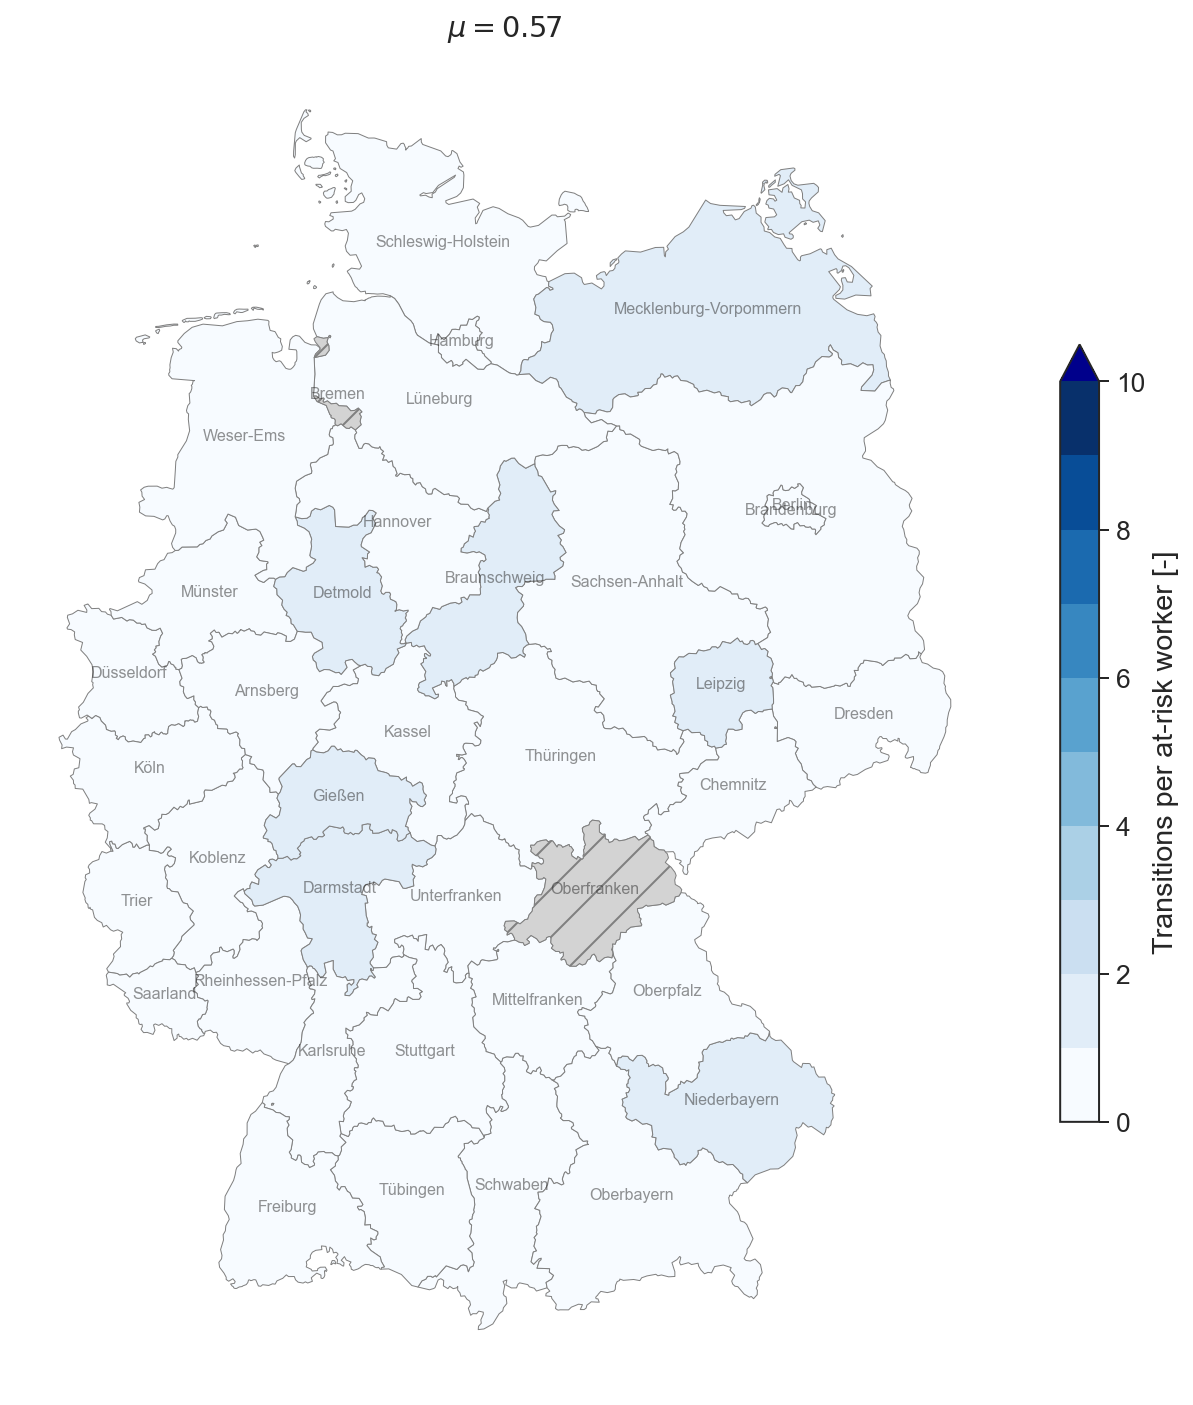

In [431]:
ax = gdf_transition_numbers_by_nuts.plot(
    column="n_viable_transitions_rel",
    figsize=(10, 10),
    legend=True,
    cmap=cmap_transitions,
    vmin=0,
    vmax=vmax_transitions,
    legend_kwds={
        "label": "Transitions per at-risk worker [-]",
        "fraction": 0.03,
        "extend": "max",
    },
    missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
    edgecolor="grey",
    linewidth=0.5,
)
gdf_transition_numbers_by_nuts.apply(
    lambda x: ax.annotate(
        text=x.NUTS_NAME,
        xy=x.geometry.centroid.coords[0],
        ha="center",
        alpha=0.5,
        rotation=0,
        fontsize=8,
    ),
    axis=1,
)


ax.set_title(
    "$\mu = {:.2f}$".format(
        gdf_transition_numbers_by_nuts.n_viable_transitions_rel.mean()
    )
)
ax.axis("off")
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir, out_dir, "n_transitions_by_region.png"
    ),
    dpi=300,
    bbox_inches="tight",
)

##### Regional distribution of earnings changes

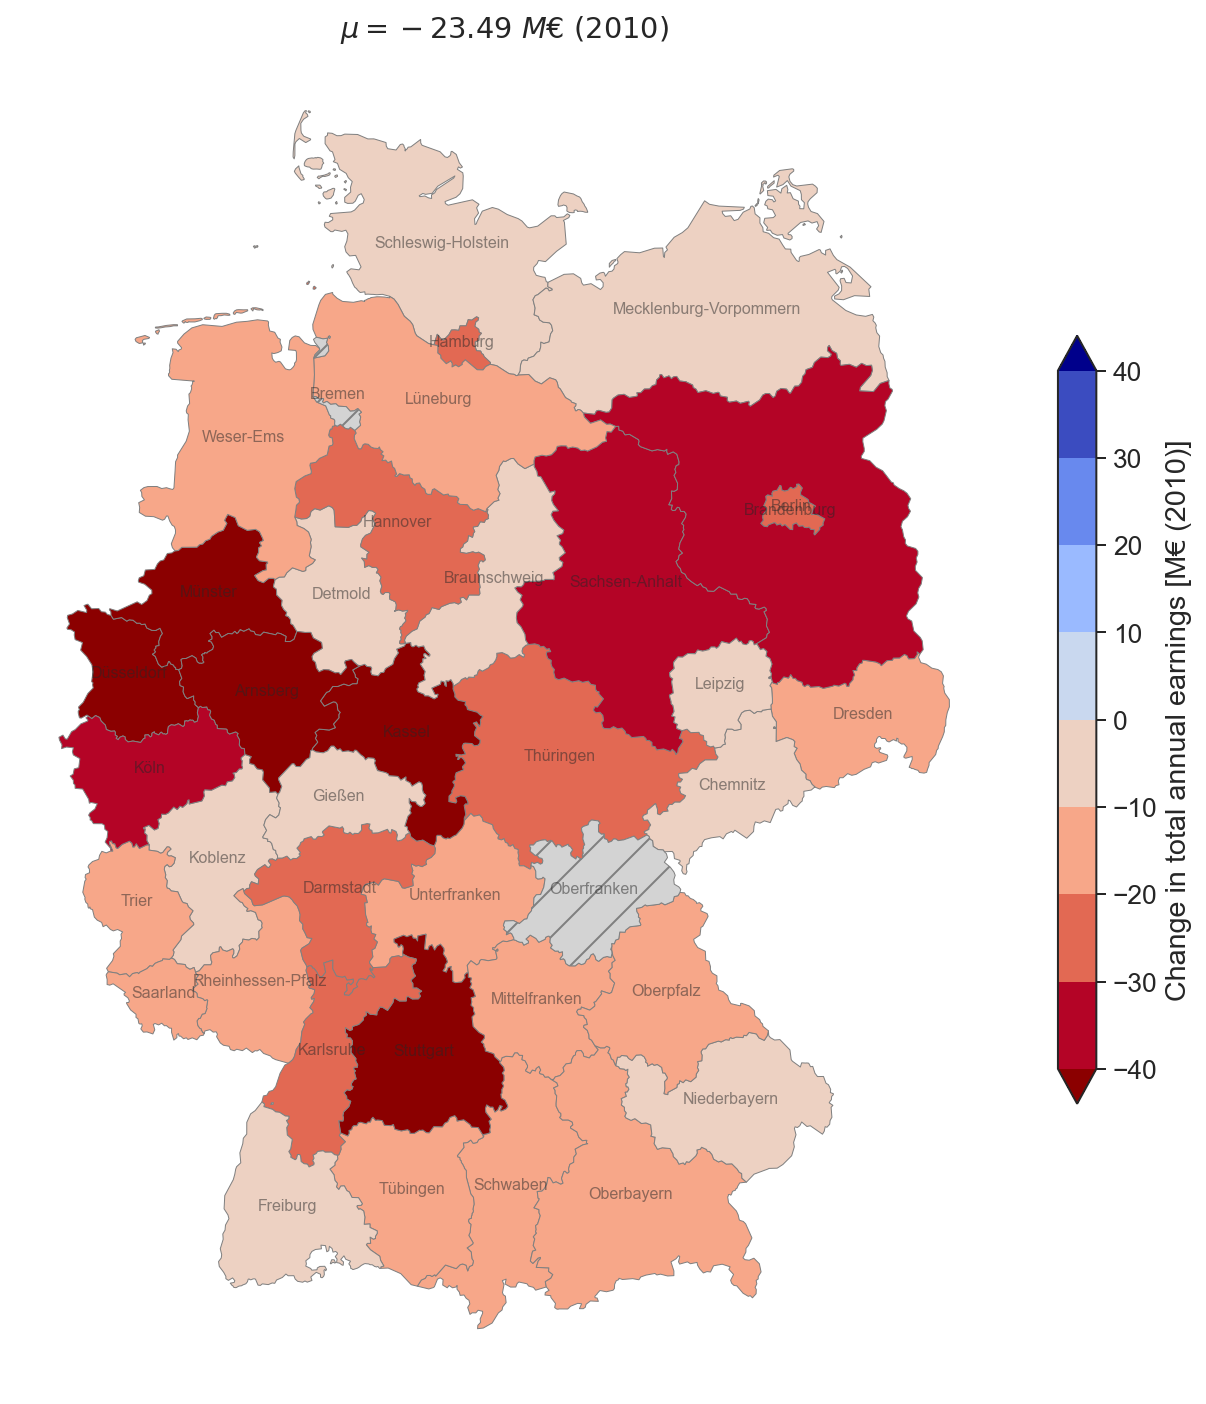

In [432]:
v = vmax_wages

ax = gdf_transition_numbers_by_nuts.plot(
    column="earnings_delta_closest_switch_sum_mio",
    figsize=(10, 10),
    legend=True,
    cmap=cmap_earnings,
    vmin=-v,
    vmax=v,
    legend_kwds={
        "label": "Change in total annual earnings [M€ (2010)]",
        "fraction": 0.03,
        "extend": "both",
    },
    missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
    edgecolor="grey",
    linewidth=0.5,
)
gdf_transition_numbers_by_nuts.apply(
    lambda x: ax.annotate(
        text=x.NUTS_NAME,
        xy=x.geometry.centroid.coords[0],
        ha="center",
        alpha=0.5,
        rotation=0,
        fontsize=8,
    ),
    axis=1,
)

ax.set_title(
    "$\mu = {:.2f}~M€~(2010)$".format(
        gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum_mio.mean()
    )
)
ax.axis("off")
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_by_region.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

##### Sectoral distribution of earnings changes (mean/median)

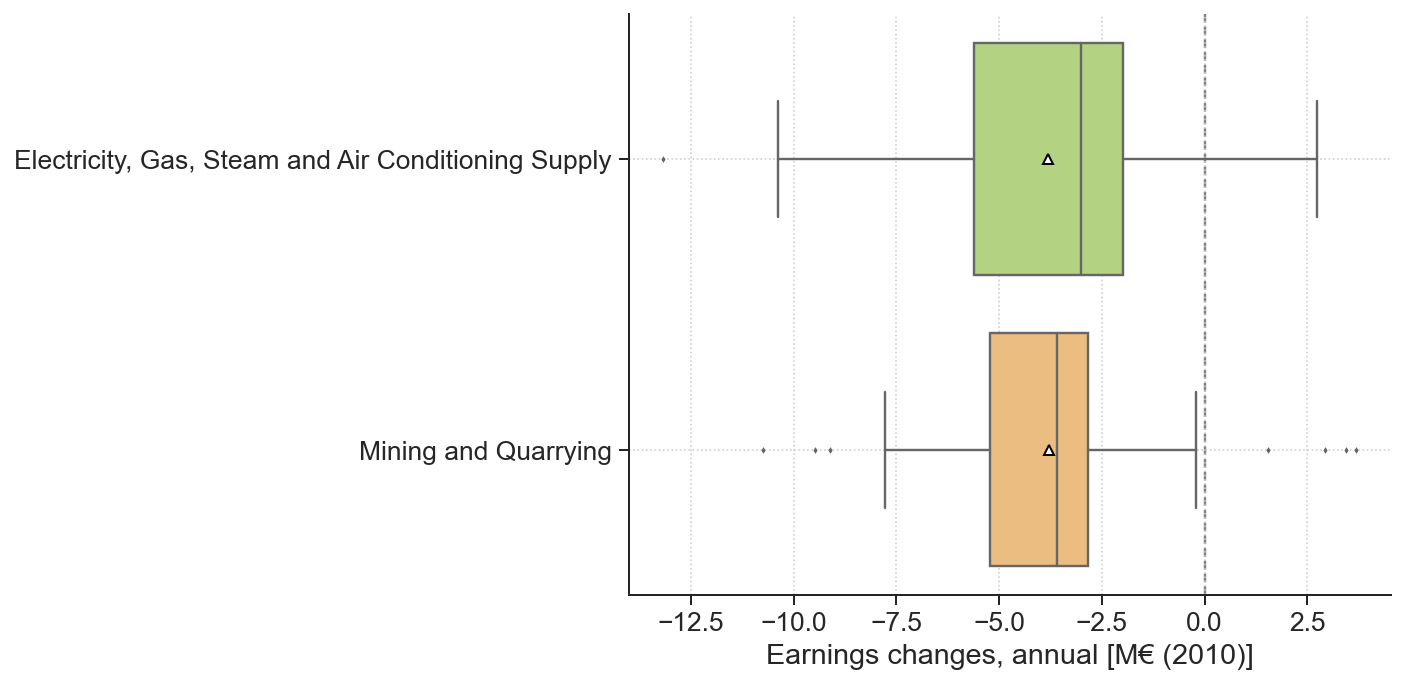

In [433]:
fig, ax = plt.subplots(figsize=(10, 5))

y_order = df_transition_numbers.groupby("NACE1D_label").median()["earnings_delta_closest_switch_sum_mio"].sort_values(ascending=False).index.values

sns.boxplot(
    data=df_transition_numbers,
    x="earnings_delta_closest_switch_sum_mio",
    y="NACE1D_label",
    orient="h",
    fliersize=1,
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "5",
    },
    order=y_order,
    palette="RdYlGn_r"
)

# sns.stripplot(
#     data=df_transition_numbers,
#     x="earnings_delta_closest_switch_sum_mio",
#     y="NACE1D_label",
#     orient="h",
#     alpha=.5,
#     edgecolor="gray",
#     linewidth=1,
#     zorder=1
# )

ax.axvline(0, linestyle="--", color="grey", zorder=0)

ax.grid(linestyle=":")
ax.set_xlabel("Earnings changes, annual [M€ (2010)]")
ax.set_ylabel(None)

sns.despine()
plt.tight_layout()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_by_industry.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

##### Sectoral distribution of earnings changes (sum)

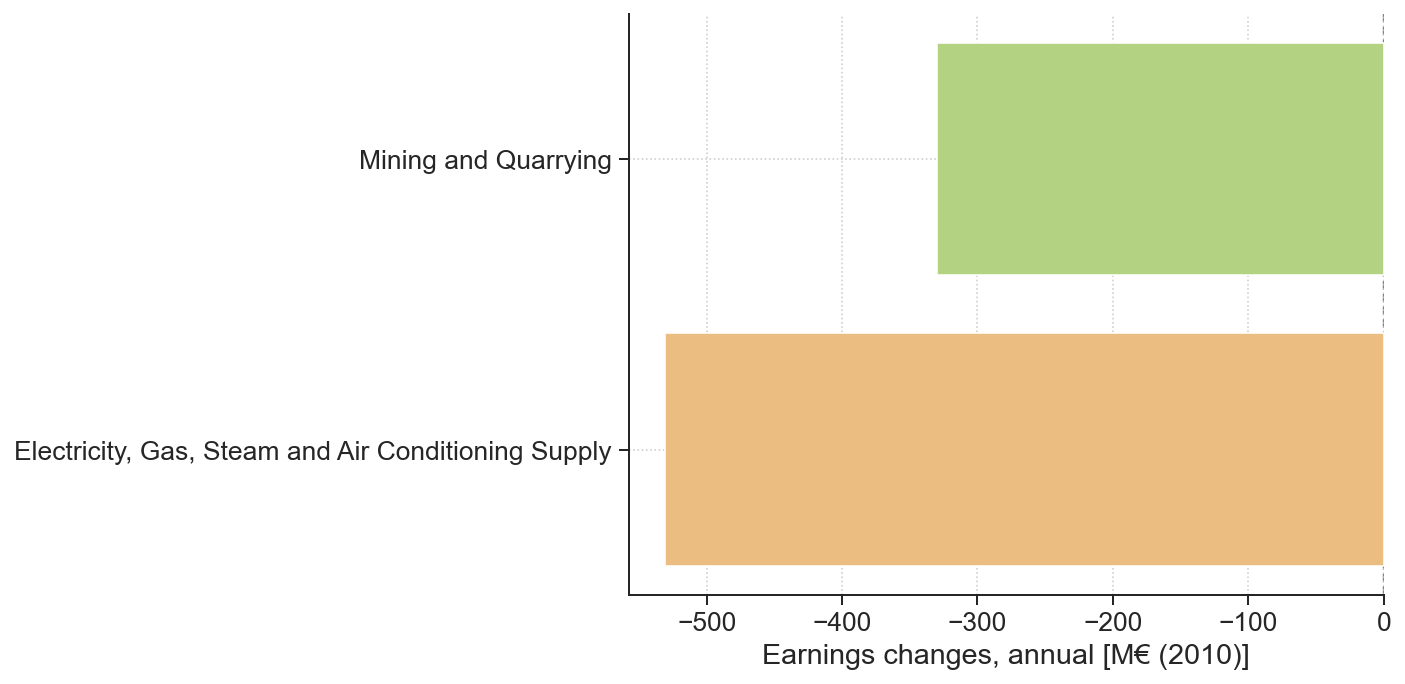

In [434]:
fig, ax = plt.subplots(figsize=(10, 5))

y_order = df_transition_numbers.groupby("NACE1D_label").sum()["earnings_delta_closest_switch_sum_mio"].sort_values(ascending=False).index.values

sns.barplot(
    data=df_transition_numbers,
    x="earnings_delta_closest_switch_sum_mio",
    y="NACE1D_label",
    orient="h",
    estimator=np.sum,
    ci=None,
    order=y_order,
    palette="RdYlGn_r"
)

ax.axvline(0, linestyle="--", color="grey", zorder=0)

ax.grid(linestyle=":")
ax.set_xlabel("Earnings changes, annual [M€ (2010)]")
ax.set_ylabel(None)

sns.despine()
plt.tight_layout()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_by_industry_sum.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

Comparison of costs with Kohleaustiegsbudget

In [435]:
earnings_losses[
    "wage_continuity"
] = gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

print(
    np.abs(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum())
    / (40 * 10**9)
)
gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

0.021143356573454238


-845734262.9381695

#### Scenario 2b) Wage continuity + regional constraint

##### Compute transitions

In [241]:
# unique regions
nuts_codes = df_de.NUTS_ID.dropna().unique()

# job availability by region
regional_job_availability = occ_number_by_nuts2_and_isco3.reset_index()

# fraction of total current jobs in (neutral or green) target occupation B that could be added to employ workers transitioning from (brown) source occupation A
max_fraction_in_target_occ = 0.1

In [245]:
%%time

results_by_region = {}
# outer loop: regions
for nuts_code in tqdm(nuts_codes):
    print(nuts_code)

    # absolute n of jobs in region per occupation category
    regional_job_availability_subset = regional_job_availability[regional_job_availability.NUTS_ID == nuts_code]

    # inner loop: at-risk jobs grouped by source occupation category
    transition_number_data = []

    # subset transition pool
    regional_transition_pool = df_transition_pool.loc[df_transition_pool["NUTS_ID"] == nuts_code]
    regional_occs = regional_transition_pool.ISCO3D_label.unique()
    print("number of at-risk jobs:", regional_transition_pool.COEFF.sum())

    for i, search_occ_label in enumerate(regional_occs):
        print(occ)
        # pool of transitioning workers in region i and occupation j
        transitions_by_occ = regional_transition_pool[regional_transition_pool.ISCO3D_label == search_occ_label]

        # absolute number of transitioning workers in region i and occupation j
        n_workers_transitioning = transitions_by_occ[transition_pool_weights].sum()

        # find index of search occ and closest target occs
        idx = df_occs.loc[df_occs.occ == search_occ_label].index.values[0]
        target_occs = find_closest(
            i=idx, similarity_matrix=similarity_matrix, df=df_occs_metadata
        )

        # filter criteria 1: sim > viability threshold
        target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]

        # filter criteria 2: target occupation is neutral or green
        target_occs_filtered = target_occs_filtered.loc[
            target_occs_filtered.category != "brown"
        ]
        target_occs_filtered = target_occs_filtered.dropna()

        # combine with job availability at regional level
        target_occs_filtered = target_occs_filtered.merge(regional_job_availability_subset, left_on="occ", right_on="ISCO3D_label", how="left", suffixes=("", "_target_regional"))

        # fraction of transitioning workers of existing workers in region i and occupation j
        target_occs_filtered["fraction_of_transitioning_workers"] =  n_workers_transitioning / target_occs_filtered["COEFF_target_regional"]

        # filter criteria 3: workers choose target occupation that minimises their earnings losses
        target_occs_filtered["wage_diff"] = (
            target_occs_filtered.annual_earnings_2016 - search_obs.annual_earnings_2016
        )

        # (optional) filter criteria 3, regional: drop target occupations that can likely not absorb the transitioning workers
        target_occs_filtered = target_occs_filtered[target_occs_filtered["fraction_of_transitioning_workers"] <= max_fraction_in_target_occ]

        print(transitions_by_occ)
        print(target_occs_filtered)

        assert 1 == 2

        # if I know the wage of the source occupation, choose transition that minimises wage losses
        if search_obs.annual_earnings_2016 != np.nan:
            target = target_occs_filtered.sort_values("wage_diff").tail(1)
        else:
            # if not, choose transition with highest target wage
            target = target_occs_filtered.sort_values("annual_earnings_2016").tail(1)

        # check if viable transition exists
        if not target.empty:
            # Every worker transitions to the next-closest job and I evaluate the wage difference
            search_obs["earnings_delta_closest_switch"] = (
                target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
            )
            search_obs["earnings_delta_closest_switch_sum"] = (
                target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
            ) * search_obs[transition_pool_weights]
            search_obs["n_viable_transitions"] = target_occs_filtered.shape[0]
            search_obs["n_viable_transitions_sum"] = (
                target_occs_filtered.shape[0] * search_obs[transition_pool_weights]
            )
            search_obs["transition_viable"] = True
            search_obs["transition_target"] = target.occ.values[0]
            search_obs["target_category"] = target.category.values[0]
        else:
            # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
            search_obs[
                "earnings_delta_closest_switch"
            ] = search_obs.annual_earnings_2016 * (-1)
            search_obs["earnings_delta_closest_switch_sum"] = (
                search_obs.annual_earnings_2016 * (-1) * search_obs[transition_pool_weights]
            )
            search_obs["n_viable_transitions"] = 0
            search_obs["n_viable_transitions_sum"] = 0
            search_obs["transition_viable"] = False
            search_obs["transition_target"] = None
            search_obs["target_category"] = None

        transition_number_data.append(search_obs)
    results_by_region[nuts_code] = transition_number_data

    # delete after
    break

results_by_region

  0%|          | 0/38 [00:00<?, ?it/s]

DE11
number of at-risk jobs: 2376.1825000000003
Mining, manufacturing and construction supervisors
       AGE  COEFF  COEFF_share_brown_sl  COEFF_share_brown_slt  \
41934   27 154.08                  5.22                   5.22   
65127   62 156.88                  5.32                   5.32   
152012  62 138.64                  4.70                   4.70   
190585  62 148.44                  5.03                   5.03   
203326  62 141.13                  4.78                   4.78   
236633  32 354.43                 12.01                  12.01   
246827  42 128.69                  4.36                   4.36   

        COEFF_share_green  COEFF_share_neutral_sl  COEFF_share_neutral_slt  \
41934               10.45                  138.41                   138.41   
65127               10.64                  140.92                   140.92   
152012               9.40                  124.54                   124.54   
190585              10.06                  133.34           

AssertionError: 

In [244]:
transitions_by_occ
search_obs

AGE                                                                                 42
COEFF                                                                           128.69
COEFF_share_brown_sl                                                              4.36
COEFF_share_brown_slt                                                             4.36
COEFF_share_green                                                                 8.72
COEFF_share_neutral_sl                                                          115.60
COEFF_share_neutral_slt                                                         115.60
COUNTRY                                                                             DE
COUNTRYW                                                                            DE
DEGURBA                                                                              2
EDUC4WN                                                                              0
FTPT                                       

In [ ]:
regional_transition_pool[regional_transition_pool.ISCO3D_label == search_obs.ISCO3D_label].sum()

## Upskilling analysis
- use stylised results from the upskilling analyis
- add skills that were found to unlock the most additional viable transitions per occupation to profile before calculating transitions
- pre-compute 4 different similarity matrices where those skills are already added

In [ ]:
df_top_skills_per_occ_all = pd.read_csv(
    os.path.join(
        useful_paths.data_interim,
        "upskilling_analysis",
        "upskilling_best_5_skills_per_isco3d_occupation.csv",
    ),
    index_col=0,
)

# subset brown occupations
df_top_skills_per_occ = df_top_skills_per_occ_all[
    df_top_skills_per_occ_all.Occupation.isin(list(transition_pool_dict.keys()))
]

if two skills unlock the same (top) number of new viable transitions, choose the one with the higher coreness

In [ ]:
isco_group_dict = dict(zip(isco_groups_labels.preferredLabel, isco_groups_labels.code))

In [ ]:
optimal_upskilling_per_occ = []
for group, df in df_top_skills_per_occ.groupby("Occupation"):
    # max new viable transitions
    t_max = df["Viable transitions"].max()
    sub_df = df[df["Viable transitions"] == t_max]

    # max coreness if multiple options
    c_max = sub_df["Coreness"].max()
    sub_sub_df = sub_df[sub_df["Coreness"] == c_max]
    optimal_upskilling_per_occ.append(sub_sub_df)

df_optimal_upskilling_per_occ = pd.concat(
    optimal_upskilling_per_occ, axis=0
).reset_index(drop=True)

# get skill id
# todo: refactor to point to MCC repository
coreness = pd.read_csv(
    os.path.join(useful_paths.data_processed, "esco", "skills_network_metrics.csv"),
    index_col=0,
)

df_optimal_upskilling_per_occ = pd.merge(
    df_optimal_upskilling_per_occ,
    coreness.reset_index()[["index", "preferredLabel"]].rename(
        columns={"preferredLabel": "Skill", "index": "id_skill"}
    ),
    on="Skill",
)

df_optimal_upskilling_per_occ["id_occ"] = [
    isco_group_dict[occ_label]
    for occ_label in df_optimal_upskilling_per_occ.Occupation.values
]

df_optimal_upskilling_per_occ.to_csv(
    os.path.join(
        useful_paths.data_interim,
        "upskilling_analysis",
        "upskilling_selected_skill_per_occupation.csv",
    )
)
df_optimal_upskilling_per_occ

In [ ]:
occ_sims_isco3 = df_occ_sims.values
np.fill_diagonal(occ_sims_isco3, 0)

In [ ]:
occ_codes = occ_skills_mat_isco3.index.values.tolist()

In [ ]:
occ = df_optimal_upskilling_per_occ.iloc[0]

# find index of occ
idx_occ = occ_codes.index(occ.id_occ)
idx_new_skill = occ.id_skill

# add skill to occ skill profile
occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

# recalc occ sim matrix
occ_sims_isco3_upskilling = np.matmul(
    occ_skills_mat_isco3_upskilling.values,
    occ_skills_mat_isco3_upskilling.values.transpose(),
)
np.fill_diagonal(occ_sims_isco3_upskilling, 0)

#### 1) Skills continuity scenario with upskilling

In [ ]:
%%time
if run_skills_continuity_scenarios:
    transition_number_data = []

    for i, search_obs in tqdm(df_transition_pool.iterrows()):

        search_label = search_obs.ISCO3D_label
        idx = df_occs.loc[df_occs.occ == search_label].index.values[0]

        # -----------------------------------------------------------------------------------------------------------------------------
        # UPSKILLING STEP
        # -----------------------------------------------------------------------------------------------------------------------------
        # conditional on the source occupation, upskill worker with the skill unlocking the highest number of new viable transitions
        upskilling_data = df_optimal_upskilling_per_occ.loc[
            df_optimal_upskilling_per_occ.Occupation == search_label
        ]

        # find index of occ
        idx_occ = occ_codes.index(upskilling_data.id_occ.values[0])
        idx_new_skill = upskilling_data.id_skill

        # add skill to occ skill profile
        occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
        occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

        # recalc occ sim matrix
        occ_sims_isco3_upskilling = np.matmul(
            occ_skills_mat_isco3_upskilling.values,
            occ_skills_mat_isco3_upskilling.values.transpose(),
        )
        np.fill_diagonal(occ_sims_isco3_upskilling, 0)

        # find closest transitions
        target_occs = find_closest(
            i=idx, similarity_matrix=occ_sims_isco3_upskilling, df=df_occs_metadata
        )

        # filter
        target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]
        target_occs_filtered = target_occs_filtered.loc[
            target_occs_filtered.category != "brown"
        ]
        target_occs_filtered = target_occs_filtered.dropna()

        # earnings delta to next closest occupation
        target = target_occs_filtered.head(1)

        # check if viable transition exists
        if not target.empty:
            # Every worker transitions to the next-closest job and I evaluate the wage difference
            search_obs["earnings_delta_closest_switch"] = (
                target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
            )
            search_obs["earnings_delta_closest_switch_sum"] = (
                target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
            ) * search_obs[transition_pool_weights]
            search_obs["n_viable_transitions"] = target_occs_filtered.shape[0]
            search_obs["n_viable_transitions_sum"] = (
                target_occs_filtered.shape[0] * search_obs[transition_pool_weights]
            )
            search_obs["transition_viable"] = True
            search_obs["transition_target"] = target.occ.values[0]
            search_obs["target_category"] = target.category.values[0]
        else:
            # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
            search_obs[
                "earnings_delta_closest_switch"
            ] = search_obs.annual_earnings_2016 * (-1)
            search_obs["earnings_delta_closest_switch_sum"] = (
                search_obs.annual_earnings_2016
                * (-1)
                * search_obs[transition_pool_weights]
            )
            search_obs["n_viable_transitions"] = 0
            search_obs["n_viable_transitions_sum"] = 0
            search_obs["transition_viable"] = False
            search_obs["transition_target"] = None
            search_obs["target_category"] = None

        transition_number_data.append(search_obs)

    # to df
    df_transition_numbers = pd.concat(transition_number_data, axis=1).T
    df_transition_numbers = df_transition_numbers.infer_objects()

    # Calculate avg number of transitions per threatened job
    df_transition_numbers_by_nuts = df_transition_numbers.groupby("NUTS_ID").sum()
    df_transition_numbers_by_nuts["n_viable_transitions_rel"] = (
        df_transition_numbers_by_nuts.n_viable_transitions_sum
        / df_transition_numbers_by_nuts[transition_pool_weights]
    )

    # to gdf
    gdf_transition_numbers_by_nuts = pd.merge(
        gdf.query("CNTR_CODE == 'DE'"),
        df_transition_numbers_by_nuts.reset_index(),
        on="NUTS_ID",
        how="left",
    )

    # PLOTS

    # TRANSITION NUMBERS
    ax = gdf_transition_numbers_by_nuts.plot(
        column="n_viable_transitions_rel",
        figsize=(10, 10),
        legend=True,
        cmap=cmap_transitions,
        vmin=0,
        vmax=vmax_transitions,
        legend_kwds={
            "label": "Viable transitions per threatened job [-]",
            "fraction": 0.03,
            "extend": "max",
        },
        missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
        edgecolor="grey",
        linewidth=0.5,
    )
    gdf_transition_numbers_by_nuts.apply(
        lambda x: ax.annotate(
            text=x.NUTS_NAME,
            xy=x.geometry.centroid.coords[0],
            ha="center",
            alpha=0.5,
            rotation=0,
            fontsize=8,
        ),
        axis=1,
    )

    # ax.set_title("Viable transitions (upskilling)")
    ax.axis("off")

    # EARNINGS LOSSES
    cmap = plt.get_cmap("RdYlGn")
    v = vmax_wages
    gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] = (
        gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] / 10**6
    )
    ax = gdf_transition_numbers_by_nuts.plot(
        column="earnings_delta_closest_switch_sum",
        figsize=(10, 10),
        legend=True,
        cmap=cmap_earnings,
        vmin=-v,
        vmax=v,
        legend_kwds={
            "label": "Change in total annual earnings [Mio € in 2010]",
            "fraction": 0.03,
            "extend": "both",
        },
        missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
        edgecolor="grey",
        linewidth=0.5,
    )
    gdf_transition_numbers_by_nuts.apply(
        lambda x: ax.annotate(
            text=x.NUTS_NAME,
            xy=x.geometry.centroid.coords[0],
            ha="center",
            alpha=0.5,
            rotation=0,
            fontsize=8,
        ),
        axis=1,
    )

    ax.set_title("Skills continuity scenario (upskilling)")
    ax.axis("off")
    plt.tight_layout()

    # totals
    earnings_losses[
        "skills_continuity_upskilling"
    ] = gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

    print(
        np.abs(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum())
        / (40 * 10**9)
    )
    gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

#### 2) Wage continuity scenario with upskilling

In [ ]:
transition_number_data_upskilling = []

for i, search_obs in tqdm(df_transition_pool.iterrows()):
    search_label = search_obs.ISCO3D_label
    idx = df_occs.loc[df_occs.occ == search_label].index.values[0]

    # -----------------------------------------------------------------------------------------------------------------------------
    # UPSKILLING STEP
    # -----------------------------------------------------------------------------------------------------------------------------
    # conditional on the source occupation, upskill worker with the skill unlocking the highest number of new viable transitions
    upskilling_data = df_optimal_upskilling_per_occ.loc[
        df_optimal_upskilling_per_occ.Occupation == search_label
    ]

    # find index of occ
    idx_occ = occ_codes.index(upskilling_data.id_occ.values[0])
    idx_new_skill = upskilling_data.id_skill

    # add skill to occ skill profile
    occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
    occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

    # recalc occ sim matrix
    occ_sims_isco3_upskilling = np.matmul(
        occ_skills_mat_isco3_upskilling.values,
        occ_skills_mat_isco3_upskilling.values.transpose(),
    )
    np.fill_diagonal(occ_sims_isco3_upskilling, 0)

    # find closest transitions
    target_occs = find_closest(
        i=idx, similarity_matrix=occ_sims_isco3_upskilling, df=df_occs_metadata
    )

    # filter: viable, green or neutral
    target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]
    target_occs_filtered = target_occs_filtered.loc[
        target_occs_filtered.category != "brown"
    ]
    target_occs_filtered = target_occs_filtered.dropna()

    # earnings delta to next closest occupation
    target_occs_filtered["wage_diff"] = (
        target_occs_filtered.annual_earnings_2016 - search_obs.annual_earnings_2016
    )

    # if I know the wage of the source occupation, choose transition that minimises wage losses
    if search_obs.annual_earnings_2016 != np.nan:
        target = target_occs_filtered.sort_values("wage_diff").tail(1)
    else:
        # if not, choose transition with highest target wage
        target = target_occs_filtered.sort_values("annual_earnings_2016").tail(1)

    # check if viable transition exists
    if not target.empty:
        # Every worker transitions to the next-closest job and I evaluate the wage difference
        search_obs["earnings_delta_closest_switch"] = (
            target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
        )
        search_obs["earnings_delta_closest_switch_sum"] = (
            target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
        ) * search_obs[transition_pool_weights]
        search_obs["n_viable_transitions"] = target_occs_filtered.shape[0]
        search_obs["n_viable_transitions_sum"] = (
            target_occs_filtered.shape[0] * search_obs[transition_pool_weights]
        )
        search_obs["transition_viable"] = True
        search_obs["transition_target"] = target.occ.values[0]
        search_obs["target_category"] = target.category.values[0]
    else:
        # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
        search_obs[
            "earnings_delta_closest_switch"
        ] = search_obs.annual_earnings_2016 * (-1)
        search_obs["earnings_delta_closest_switch_sum"] = (
            search_obs.annual_earnings_2016 * (-1) * search_obs[transition_pool_weights]
        )
        search_obs["n_viable_transitions"] = 0
        search_obs["n_viable_transitions_sum"] = 0
        search_obs["transition_viable"] = False
        search_obs["transition_target"] = None
        search_obs["target_category"] = None

    transition_number_data_upskilling.append(search_obs)

# to df
df_transition_numbers_upskilling = pd.concat(transition_number_data_upskilling, axis=1).T
df_transition_numbers_upskilling = df_transition_numbers_upskilling.infer_objects()

# scale
df_transition_numbers_upskilling["earnings_delta_closest_switch_sum_mio"] = (
    df_transition_numbers_upskilling["earnings_delta_closest_switch_sum"] / 10**6
)

# Calculate avg number of transitions per threatened job
df_transition_numbers_upskilling_by_nuts = df_transition_numbers_upskilling.groupby("NUTS_ID").sum()
df_transition_numbers_upskilling_by_nuts["n_viable_transitions_rel"] = (
    df_transition_numbers_upskilling_by_nuts.n_viable_transitions_sum
    / df_transition_numbers_upskilling_by_nuts[transition_pool_weights]
)

# to gdf
gdf_transition_numbers_upskilling_by_nuts = pd.merge(
    gdf.query("CNTR_CODE == 'DE'"),
    df_transition_numbers_upskilling_by_nuts.reset_index(),
    on="NUTS_ID",
    how="left",
)

##### Regional distribution of transition pathways

In [ ]:
ax = gdf_transition_numbers_upskilling_by_nuts.plot(
    column="n_viable_transitions_rel",
    figsize=(10, 10),
    legend=True,
    cmap=cmap_transitions,
    vmin=0,
    vmax=vmax_transitions,
    legend_kwds={
        "label": "Transitions per at-risk worker [-]",
        "fraction": 0.03,
        "extend": "max",
    },
    missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
    edgecolor="grey",
    linewidth=0.5,
)
gdf_transition_numbers_upskilling_by_nuts.apply(
    lambda x: ax.annotate(
        text=x.NUTS_NAME,
        xy=x.geometry.centroid.coords[0],
        ha="center",
        alpha=0.5,
        rotation=0,
        fontsize=8,
    ),
    axis=1,
)


ax.set_title(
    "$\mu = {:.2f}$".format(
        gdf_transition_numbers_upskilling_by_nuts.n_viable_transitions_rel.mean()
    )
)
ax.axis("off")
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "n_transitions_by_region_upskilling.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

##### Regional distribution of earnings changes

In [ ]:
v = vmax_wages

ax = gdf_transition_numbers_upskilling_by_nuts.plot(
    column="earnings_delta_closest_switch_sum_mio",
    figsize=(10, 10),
    legend=True,
    cmap=cmap_earnings,
    vmin=-v,
    vmax=v,
    legend_kwds={
        "label": "Change in total annual earnings [M€ (2010)]",
        "fraction": 0.03,
        "extend": "both",
    },
    missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
    edgecolor="grey",
    linewidth=0.5,
)
gdf_transition_numbers_upskilling_by_nuts.apply(
    lambda x: ax.annotate(
        text=x.NUTS_NAME,
        xy=x.geometry.centroid.coords[0],
        ha="center",
        alpha=0.5,
        rotation=0,
        fontsize=8,
    ),
    axis=1,
)

ax.set_title(
    "$\mu = {:.2f}~M€$".format(
        gdf_transition_numbers_upskilling_by_nuts.earnings_delta_closest_switch_sum_mio.mean()
    )
)
ax.axis("off")

plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_by_region_upskilling.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

gdf_transition_numbers_upskilling_by_nuts.earnings_delta_closest_switch_sum_mio.sum()

##### Sectoral distribution of earnings changes (mean/median)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

y_order = df_transition_numbers_upskilling.groupby("NACE1D_label").median()["earnings_delta_closest_switch_sum_mio"].sort_values(ascending=False).index.values

sns.boxplot(
    data=df_transition_numbers_upskilling,
    x="earnings_delta_closest_switch_sum_mio",
    y="NACE1D_label",
    orient="h",
    fliersize=1,
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "5",
    },
    order=y_order,
    palette="RdYlGn_r"
)

# sns.stripplot(
#     data=df_transition_numbers_upskilling,
#     x="earnings_delta_closest_switch_sum_mio",
#     y="NACE1D_label",
#     orient="h",
#     alpha=.5,
#     edgecolor="gray",
#     linewidth=1,
#     zorder=1
# )

ax.axvline(0, linestyle="--", color="grey", zorder=0)

ax.grid(linestyle=":")
ax.set_xlabel("Earnings changes, annual [M€ (2010)]")
ax.set_ylabel(None)

sns.despine()
plt.tight_layout()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_by_industry_upskilling.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

##### Sectoral distribution of earnings changes (sum)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

y_order = df_transition_numbers_upskilling.groupby("NACE1D_label").sum()["earnings_delta_closest_switch_sum_mio"].sort_values(ascending=False).index.values

sns.barplot(
    data=df_transition_numbers_upskilling,
    x="earnings_delta_closest_switch_sum_mio",
    y="NACE1D_label",
    orient="h",
    estimator=np.sum,
    ci=None,
    order=y_order,
    palette="RdYlGn_r"
)

ax.axvline(0, linestyle="--", color="grey", zorder=0)

ax.grid(linestyle=":")
ax.set_xlabel("Earnings changes, annual [M€ (2010)]")
ax.set_ylabel(None)

sns.despine()
plt.tight_layout()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_by_industry_sum_upskilling.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

In [ ]:
earnings_losses[
    "wage_continuity_upskilling"
] = gdf_transition_numbers_upskilling_by_nuts.earnings_delta_closest_switch_sum.sum()

print(
    np.abs(gdf_transition_numbers_upskilling_by_nuts.earnings_delta_closest_switch_sum.sum())
    / (40 * 10**9)
)

### Comparison of earnings losses across scenarios

In [ ]:
df_earnings_losses = pd.DataFrame.from_dict(
    earnings_losses, orient="index", columns=["annual_earnings_delta"]
)
df_earnings_losses.index.name = "scenario"
wage_scenario = df_earnings_losses.reset_index()
wage_scenario["annual_earnings_delta_mio"] = wage_scenario["annual_earnings_delta"] / 10**6

In [ ]:
fig, ax = plt.subplots(figsize=(5, 8))
sns.barplot(
    data=wage_scenario,
    x="scenario",
    y="annual_earnings_delta_mio",
    ax=ax,
    zorder=2,
)

sns.despine()

ax.set_xlabel(None)
ax.set_ylabel("Change in total annual earnings [M€ (2010)]")

plt.xticks(np.arange(2), ["Before", "After"])
plt.grid(axis="y", linestyle="--", zorder=0)

plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_comparison.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=wage_scenario,
    y="scenario",
    x="annual_earnings_delta_mio",
    ax=ax,
    zorder=2,
    orient="h",
)

sns.despine()

ax.set_ylabel(None)
ax.set_xlabel("Change in total annual earnings [M€ (2010)]")

plt.yticks(np.arange(2), ["Before", "After"])
plt.grid(axis="x", linestyle="--", zorder=0)

plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        out_dir,
        "earnings_losses_comparison.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

Pension in Germany with 67 years

In [ ]:
median_age_coal_workers = 52
pension_age = 67
age_delta = pension_age - median_age_coal_workers

wage_scenario["earnings_delta_mio_15yrs"] = wage_scenario.annual_earnings_delta_mio * age_delta
wage_scenario